In [12]:
# 24i-6517
# Lab03

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from PIL import Image

plt.rcParams['figure.figsize'] = (8, 5)

In [14]:
# Data cleaning
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df = df.drop_duplicates()
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)
for c in ['Ship Mode','Segment','Region','Category','Sub-Category','State','City']:
    df[c] = df[c].str.strip()
df.to_csv('24i-6517_Lab03_cleaned.csv', index=False)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


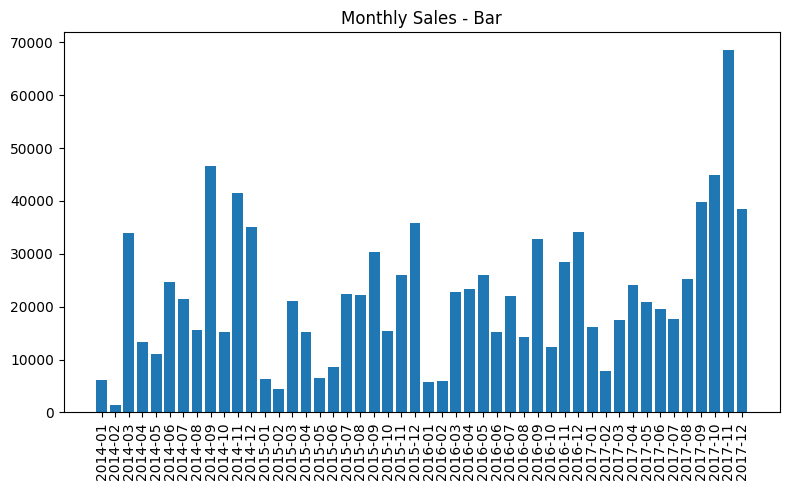

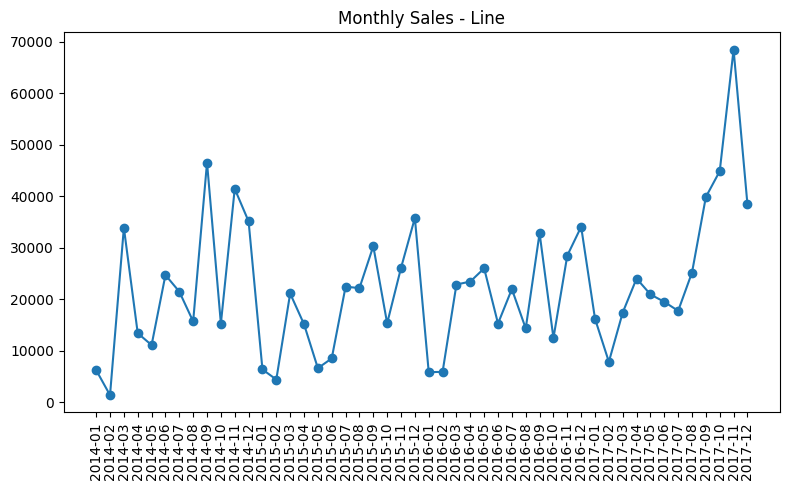

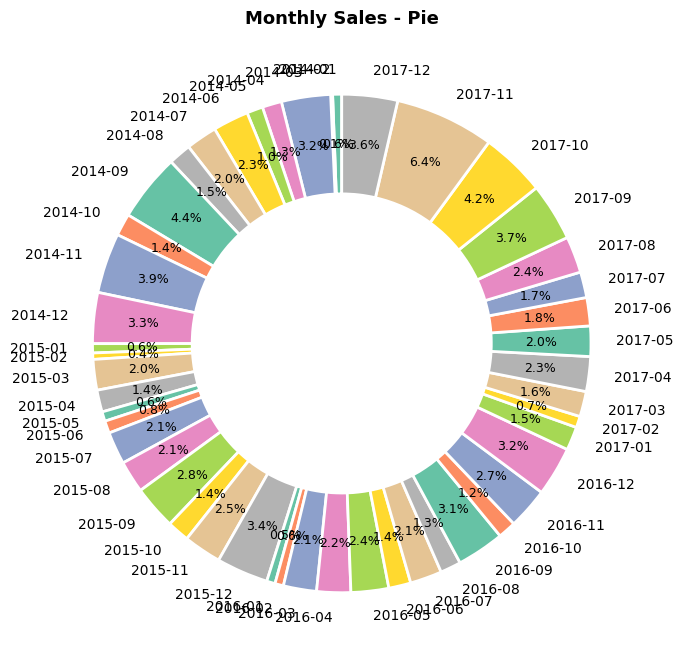

In [31]:
# Task 1
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().sort_index()
monthly_sales.index = monthly_sales.index.astype(str)

fig, ax = plt.subplots()
ax.bar(monthly_sales.index, monthly_sales.values)
plt.xticks(rotation=90)
plt.title('Monthly Sales - Bar')
plt.tight_layout()
plt.savefig('t1_bar.png')
plt.show()

fig, ax = plt.subplots()
ax.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xticks(rotation=90)
plt.title('Monthly Sales - Line')
plt.tight_layout()
plt.savefig('t1_line.png')
plt.show()

# Task 1
fig, ax = plt.subplots(figsize=(7, 7))
colors = sns.color_palette('Set2', n_colors=len(monthly_sales))
wedges, texts, autotexts = ax.pie(
    monthly_sales.values,
    labels=monthly_sales.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_color('black')
    t.set_fontsize(9)
plt.title('Monthly Sales - Pie', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('t1_pie.png', dpi=150)
plt.show()

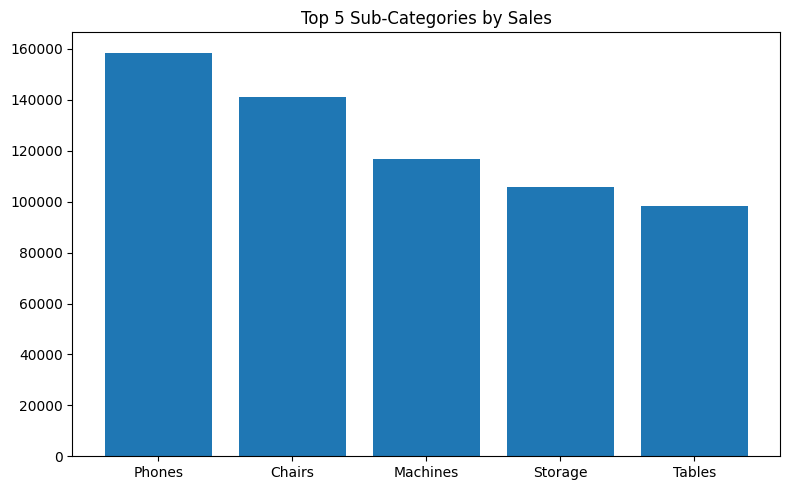

In [16]:
# Task 2a
top5_subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots()
ax.bar(top5_subcat.index, top5_subcat.values)
plt.title('Top 5 Sub-Categories by Sales')
plt.tight_layout()
plt.savefig('t2a_bar.png')
plt.show()

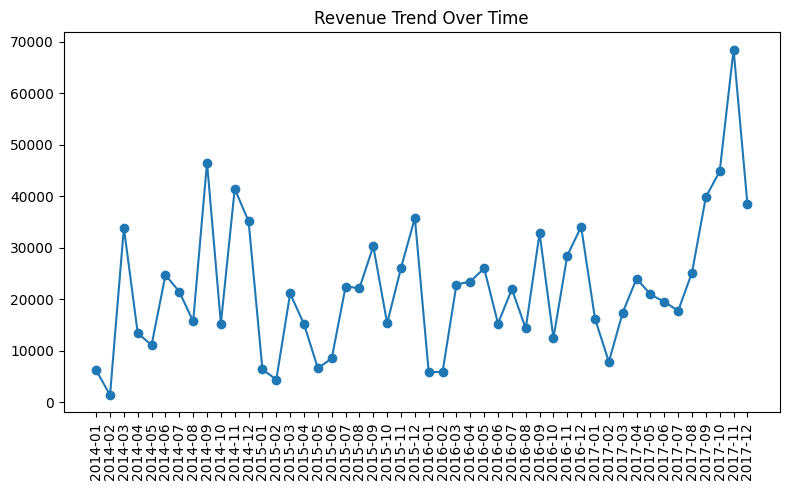

In [17]:
# Task 2b
fig, ax = plt.subplots()
ax.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xticks(rotation=90)
plt.title('Revenue Trend Over Time')
plt.tight_layout()
plt.savefig('t2b_line.png')
plt.show()

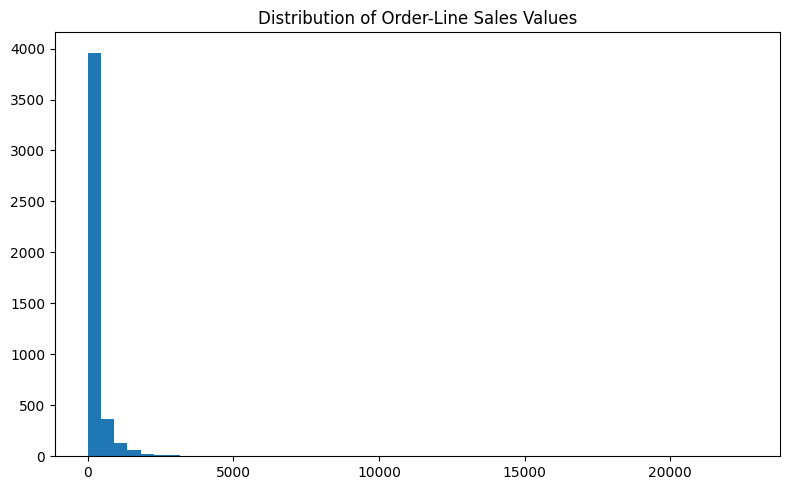

In [18]:
# Task 2c
fig, ax = plt.subplots()
ax.hist(df['Sales'], bins=50)
plt.title('Distribution of Order-Line Sales Values')
plt.tight_layout()
plt.savefig('t2c_hist.png')
plt.show()

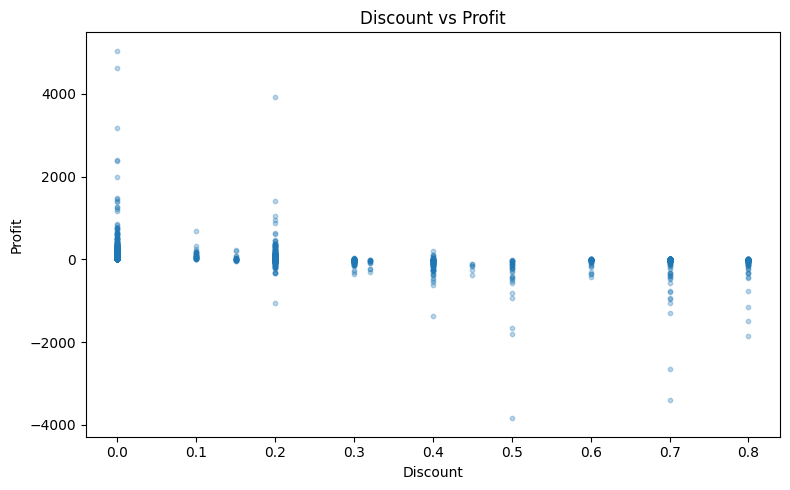

In [19]:
# Task 2d
fig, ax = plt.subplots()
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, s=10)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.tight_layout()
plt.savefig('t2d_scatter.png')
plt.show()

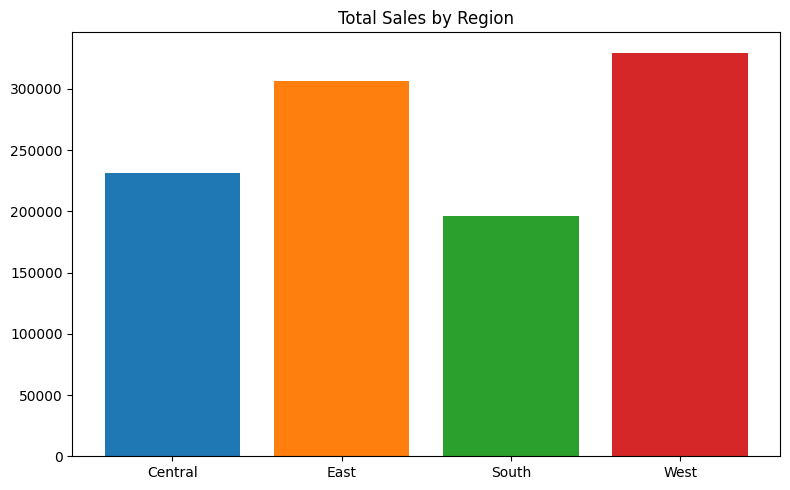

In [20]:
# Task 3a
region_sales = df.groupby('Region')['Sales'].sum()
palette = sns.color_palette('tab10', n_colors=len(region_sales))

fig, ax = plt.subplots()
ax.bar(region_sales.index, region_sales.values, color=palette)
plt.title('Total Sales by Region')
plt.tight_layout()
plt.savefig('t3a_bar.png')
plt.show()

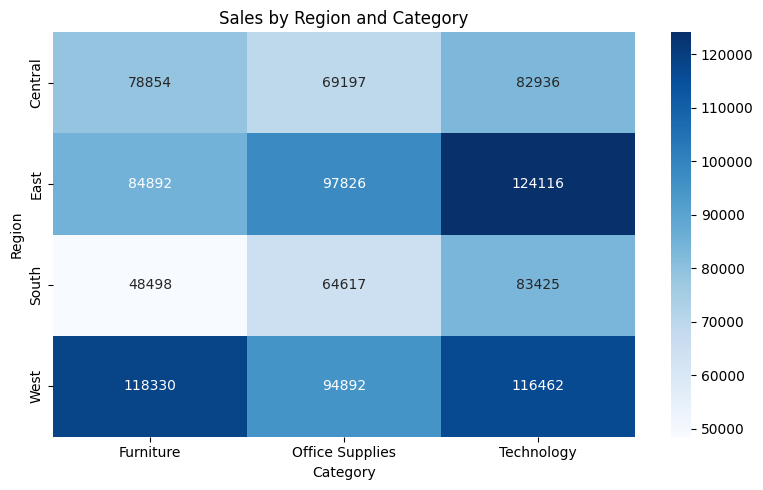

In [21]:
# Task 3b
region_category = df.groupby(['Region','Category'])['Sales'].sum().unstack()

fig, ax = plt.subplots()
sns.heatmap(region_category, cmap='Blues', annot=True, fmt='.0f', ax=ax)
plt.title('Sales by Region and Category')
plt.tight_layout()
plt.savefig('t3b_heatmap.png')
plt.show()

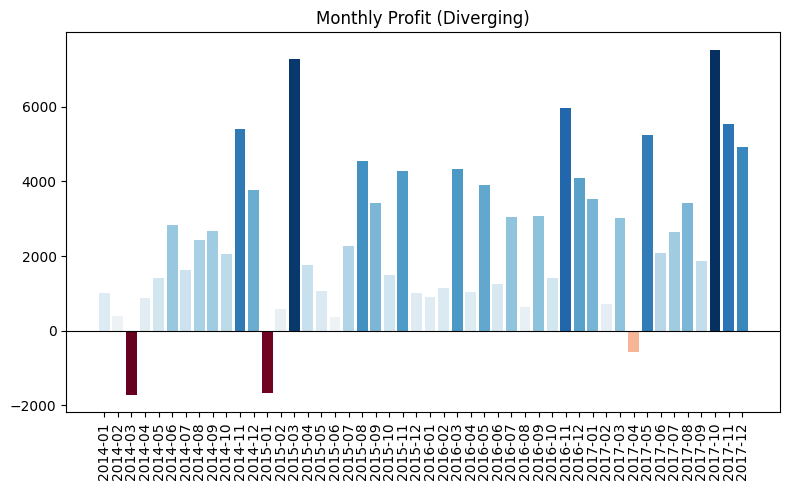

In [22]:
# Task 3c
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum().sort_index()
monthly_profit.index = monthly_profit.index.astype(str)
norm = mcolors.TwoSlopeNorm(vmin=monthly_profit.min(), vcenter=0, vmax=monthly_profit.max())
colors = plt.cm.RdBu(norm(monthly_profit.values))

fig, ax = plt.subplots()
ax.bar(monthly_profit.index, monthly_profit.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=90)
plt.title('Monthly Profit (Diverging)')
plt.tight_layout()
plt.savefig('t3c_diverging.png')
plt.show()

In [23]:
# Task 4a
def relative_luminance(rgb):
    rgb = [c/255 for c in rgb]
    rgb = [c/12.92 if c <= 0.03928 else ((c+0.055)/1.055)**2.4 for c in rgb]
    return 0.2126*rgb[0] + 0.7152*rgb[1] + 0.0722*rgb[2]

def contrast_ratio(rgb1, rgb2):
    l1 = relative_luminance(rgb1)
    l2 = relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

white = (255, 255, 255)
test_colors = {}
for name, c in zip(region_sales.index, palette):
    test_colors[f'categorical_{name}'] = tuple(int(x*255) for x in c)
test_colors['sequential_light'] = tuple(int(x*255) for x in plt.cm.Blues(0.1)[:3])
test_colors['sequential_dark'] = tuple(int(x*255) for x in plt.cm.Blues(0.9)[:3])
test_colors['diverging_low'] = tuple(int(x*255) for x in plt.cm.RdBu(0.0)[:3])
test_colors['diverging_high'] = tuple(int(x*255) for x in plt.cm.RdBu(1.0)[:3])

for name, rgb in test_colors.items():
    ratio = contrast_ratio(rgb, white)
    status = 'PASS' if ratio >= 4.5 else 'FAIL'
    print(f'{name}: {ratio:.2f} - {status}')

categorical_Central: 4.82 - PASS
categorical_East: 2.53 - FAIL
categorical_South: 3.40 - FAIL
categorical_West: 5.02 - PASS
sequential_light: 1.18 - FAIL
sequential_dark: 8.85 - PASS
diverging_low: 13.15 - PASS
diverging_high: 13.11 - PASS


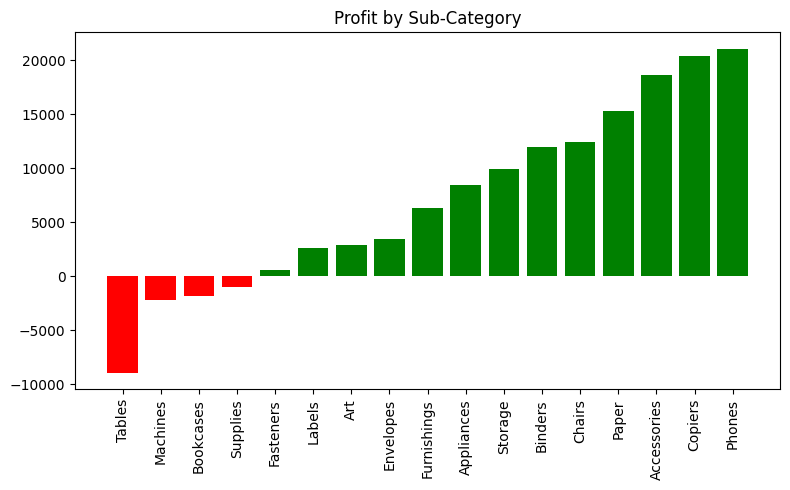

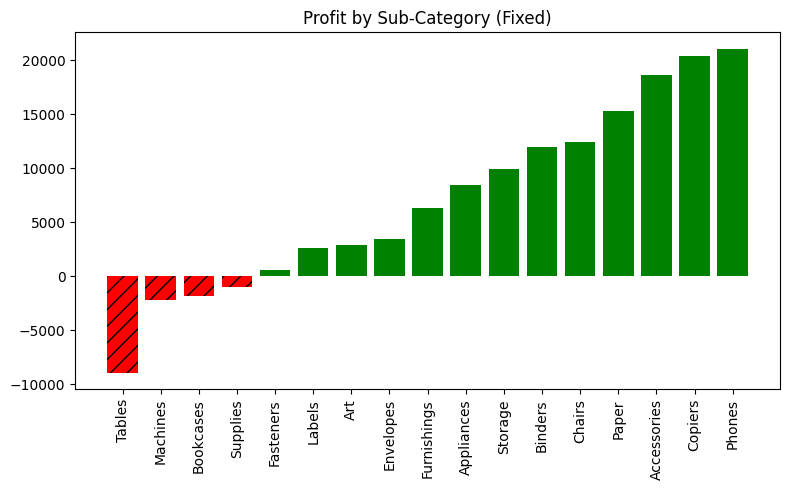

Bar chart of profit by sub-category, loss bars in red with diagonal hatching, gain bars in green with no hatching.


In [24]:
# Task 4b
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
rg_colors = ['red' if v < 0 else 'green' for v in subcat_profit.values]

fig, ax = plt.subplots()
ax.bar(subcat_profit.index, subcat_profit.values, color=rg_colors)
plt.xticks(rotation=90)
plt.title('Profit by Sub-Category')
plt.tight_layout()
plt.savefig('t4b_before.png')
plt.show()
plt.close()

def simulate_protanopia(image_path, out_path):
    matrix = np.array([[0.567, 0.433, 0.0],
                        [0.558, 0.442, 0.0],
                        [0.0,   0.242, 0.758]])
    img = Image.open(image_path).convert('RGB')
    arr = np.array(img) / 255.0
    sim = arr @ matrix.T
    sim = np.clip(sim, 0, 1) * 255
    Image.fromarray(sim.astype(np.uint8)).save(out_path)

simulate_protanopia('t4b_before.png', 't4b_before_cvd.png')

hatches = ['//' if v < 0 else '' for v in subcat_profit.values]
fig, ax = plt.subplots()
bars = ax.bar(subcat_profit.index, subcat_profit.values, color=rg_colors)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)
plt.xticks(rotation=90)
plt.title('Profit by Sub-Category (Fixed)')
plt.tight_layout()
plt.savefig('t4b_after.png')
plt.show()
plt.close()

simulate_protanopia('t4b_after.png', 't4b_after_cvd.png')

alt_text = 'Bar chart of profit by sub-category, loss bars in red with diagonal hatching, gain bars in green with no hatching.'
print(alt_text)

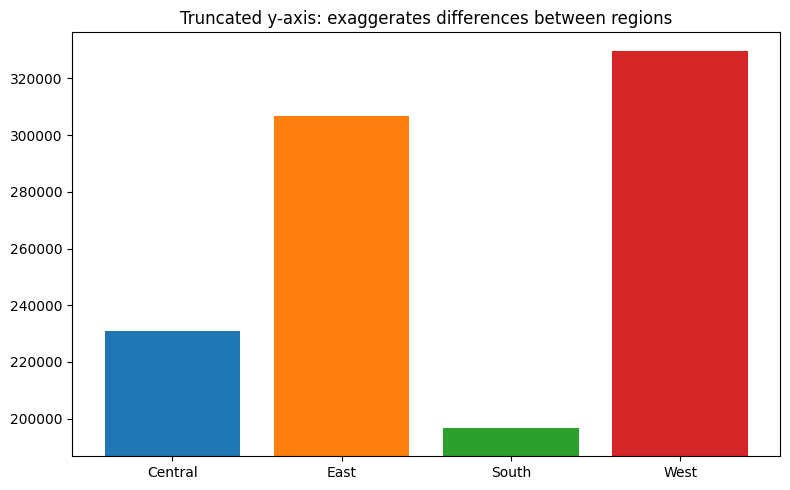

In [25]:
# Task 5.1
fig, ax = plt.subplots()
ax.bar(region_sales.index, region_sales.values, color=palette)
ax.set_ylim(region_sales.min()*0.95, region_sales.max()*1.02)
plt.title('Truncated y-axis: exaggerates differences between regions')
plt.tight_layout()
plt.savefig('t5_1_truncated.png')
plt.show()

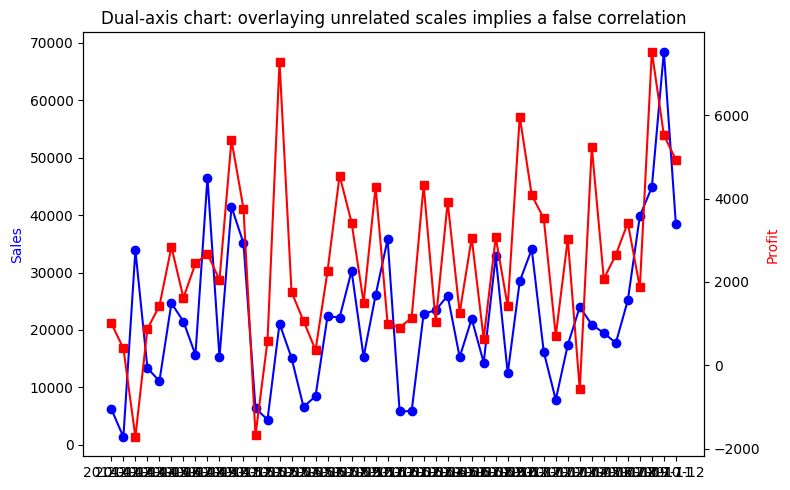

In [26]:
# Task 5.2
fig, ax1 = plt.subplots()
ax1.plot(monthly_sales.index, monthly_sales.values, color='blue', marker='o')
ax1.set_ylabel('Sales', color='blue')
ax2 = ax1.twinx()
ax2.plot(monthly_profit.index, monthly_profit.values, color='red', marker='s')
ax2.set_ylabel('Profit', color='red')
plt.xticks(rotation=90)
plt.title('Dual-axis chart: overlaying unrelated scales implies a false correlation')
plt.tight_layout()
plt.savefig('t5_2_dualaxis.png')
plt.show()

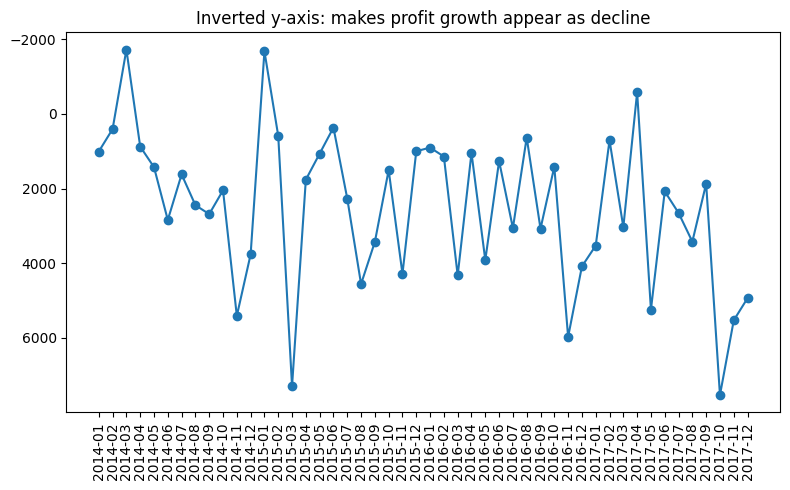

In [27]:
# Task 5.3
fig, ax = plt.subplots()
ax.plot(monthly_profit.index, monthly_profit.values, marker='o')
ax.invert_yaxis()
plt.xticks(rotation=90)
plt.title('Inverted y-axis: makes profit growth appear as decline')
plt.tight_layout()
plt.savefig('t5_3_inverted.png')
plt.show()

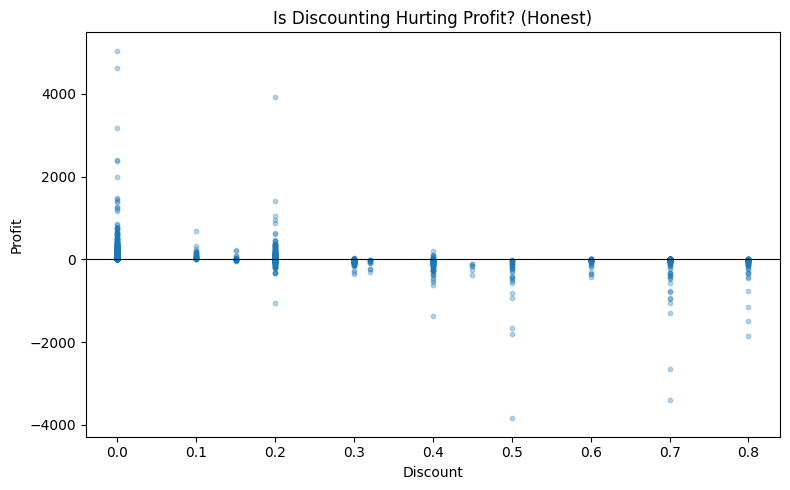

/tmp/ipykernel_4714/4072996616.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_profit_by_bin = df.groupby(disc_bins)['Profit'].mean()


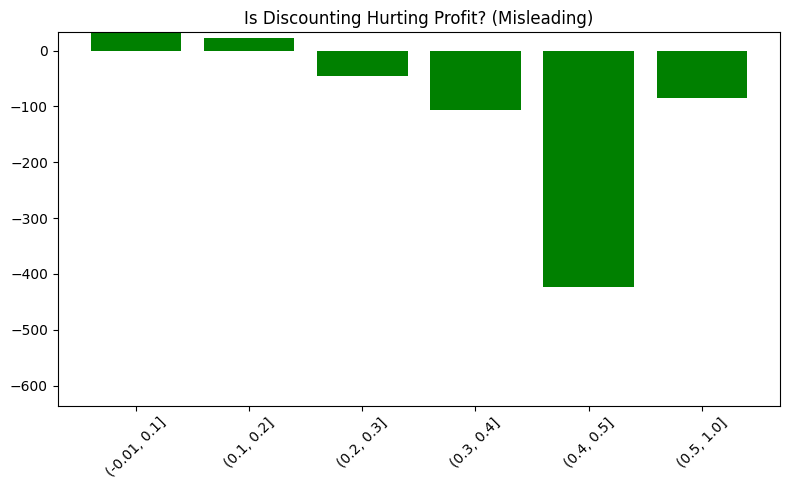

In [28]:
# Task 6
fig, ax = plt.subplots()
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, s=10)
ax.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Is Discounting Hurting Profit? (Honest)')
plt.tight_layout()
plt.savefig('t6_honest.png')
plt.show()

disc_bins = pd.cut(df['Discount'], bins=[-0.01,0.1,0.2,0.3,0.4,0.5,1.0])
avg_profit_by_bin = df.groupby(disc_bins)['Profit'].mean()

fig, ax = plt.subplots()
ax.bar(avg_profit_by_bin.index.astype(str), avg_profit_by_bin.values, color='green')
ax.set_ylim(avg_profit_by_bin.min()*1.5, avg_profit_by_bin.max()*0.5)
plt.xticks(rotation=45)
plt.title('Is Discounting Hurting Profit? (Misleading)')
plt.tight_layout()
plt.savefig('t6_misleading.png')
plt.show()